In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Comment Category Prediction Challenge

In this project, we will work on the task of classifying the type of users' comments based on their text and structured attributes. This will be an example of multi-class classification since each comment gets classified to one particular label. The data consists of both text and metadata like user interactions and topics. The target here is to conduct EDA, develop useful features, and construct a machine learning model for classification.

In [7]:
# loading the dataset

train_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_submission = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

In [8]:
# making a copy of the dataset

train_df = train_data.copy()
test_df = test_data.copy()

# Exploratory Data Analysis

In [9]:
train_df

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,NaN,NaN,NaN,False,Why save people who are bent on self-destructi...,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,NaN,NaN,NaN,False,Trudeau is not only undemocratic but also innu...,2
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,block all exports no humanitarian relief and a...,3
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1


This dataset consists of both textual and structured data, therefore making the classification problem a hybrid one. The rows represent comments, while the target feature represents the label of the category.

In [10]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [11]:
train_df.tail()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,NaN,NaN,NaN,False,Why save people who are bent on self-destructi...,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,NaN,NaN,NaN,False,Trudeau is not only undemocratic but also innu...,2
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,block all exports no humanitarian relief and a...,3
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1
197999,2023-08-26 19:36:00.380158+00:00,72,0,0,0,1,0,4,4,none,none,none,False,"Sounds likely since: ""But now scientists have ...",0


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [13]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [14]:
# To understand the available features, identify the target variable, and prepare for feature selection

train_df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [15]:
# size and dimensionality of our training data

train_df.shape

(198000, 15)

### Data Visualisation

Lets deep dive into Patterns, trends and correlations in our Data

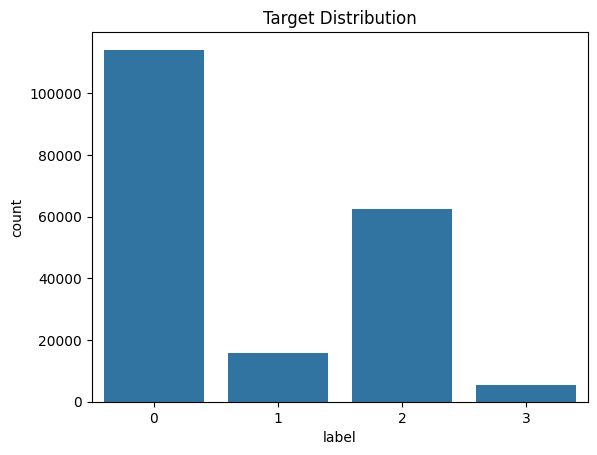

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


In [16]:
# Target distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=train_df)
plt.title("Target Distribution")
plt.show()

print(train_df['label'].value_counts(normalize=True))

* The dataset likely shows **uneven class distribution**, meaning some labels have significantly more samples than others.
* This suggests the model may favor majority classes, so handling imbalance will be important for better performance.


array([[<Axes: title={'center': 'post_id'}>,
        <Axes: title={'center': 'emoticon_1'}>,
        <Axes: title={'center': 'emoticon_2'}>],
       [<Axes: title={'center': 'emoticon_3'}>,
        <Axes: title={'center': 'upvote'}>,
        <Axes: title={'center': 'downvote'}>],
       [<Axes: title={'center': 'if_1'}>,
        <Axes: title={'center': 'if_2'}>,
        <Axes: title={'center': 'label'}>]], dtype=object)

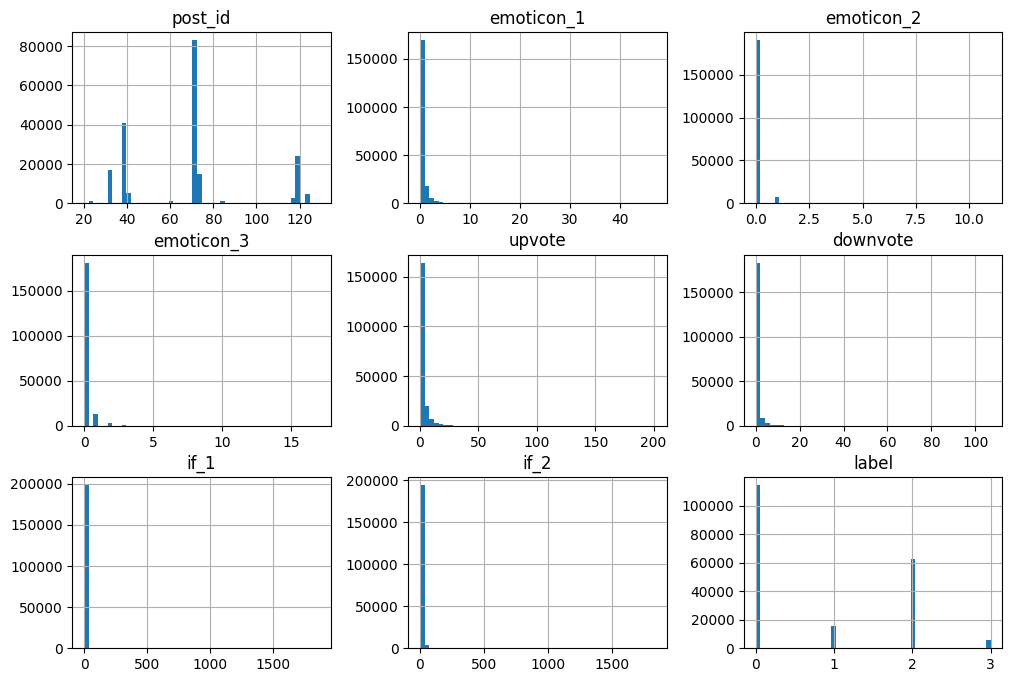

In [17]:
train_df.hist(bins=50,figsize=(12,8))

* The histograms show the **distribution of all numerical features**, revealing their spread and shape.
* It indicates that many features are **skewed and may require transformation or scaling** for better model performance.

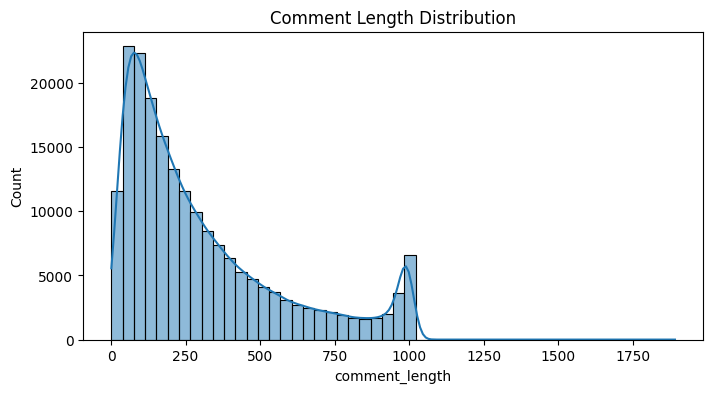

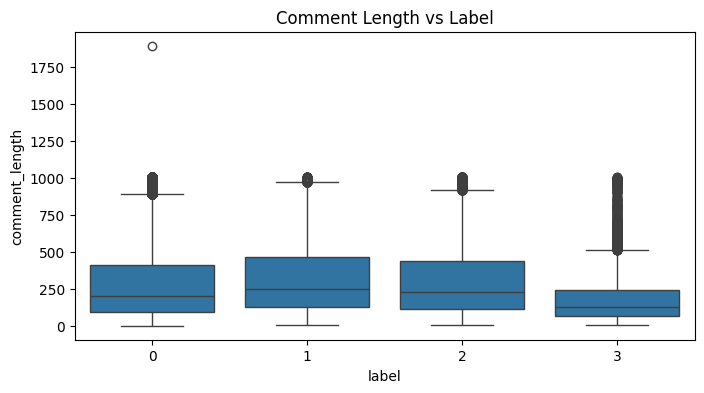

In [18]:
## Text feature analysis (comment)

# Length of comments
train_df['comment_length'] = train_df['comment'].astype(str).apply(len)

plt.figure(figsize=(8,4))
sns.histplot(train_df['comment_length'], bins=50, kde=True)
plt.title("Comment Length Distribution")
plt.show()

# Compare by class
plt.figure(figsize=(8,4))
sns.boxplot(x='label', y='comment_length', data=train_df)
plt.title("Comment Length vs Label")
plt.show()

* The distribution shows that comment lengths vary widely, indicating presence of both short and long texts in the dataset.
* The boxplot suggests that different labels may have distinct length patterns, making comment length a potentially useful feature for classification.

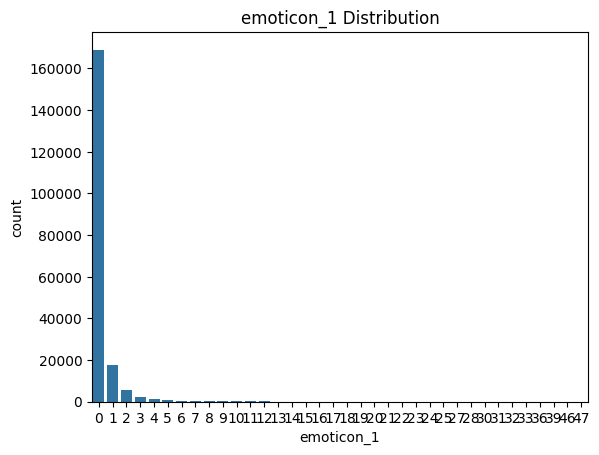

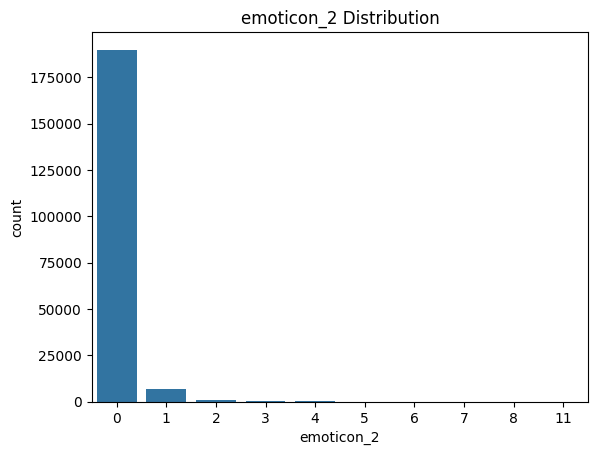

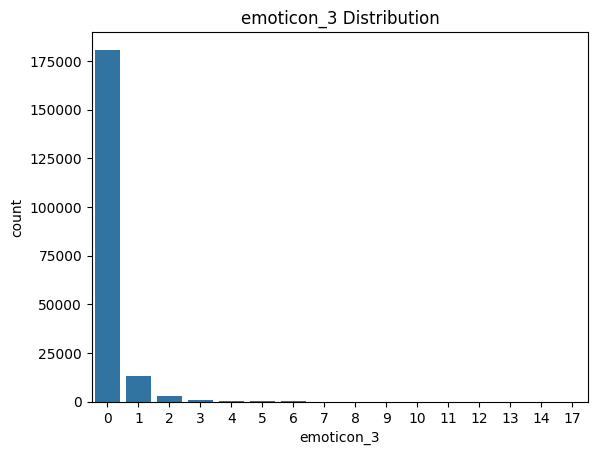

In [19]:
# Emoticon features analysis 

emoticon_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3']

for col in emoticon_cols:
    sns.countplot(x=col, data=train_df)
    plt.title(f"{col} Distribution")
    plt.show()

* The distribution of emoticon features shows that certain emoticons occur more frequently than others, indicating non-uniform usage patterns.
* These patterns suggest that emoticons may carry predictive signals and can help in distinguishing between different classes.

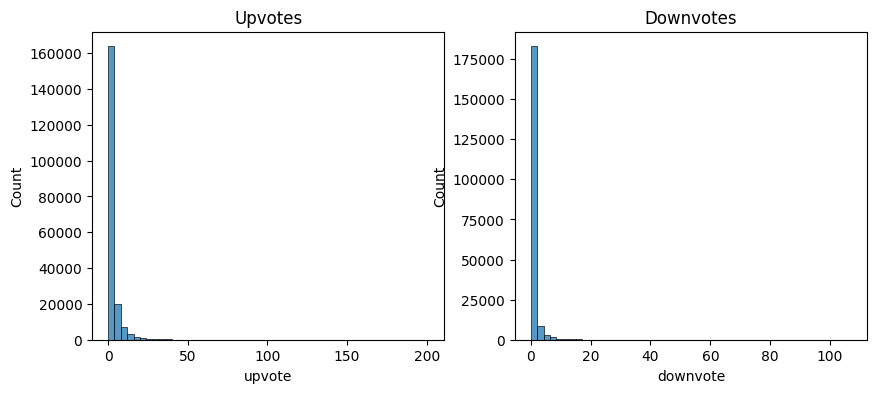

In [20]:
# Engagement features (upvote, downvote) 

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(train_df['upvote'], bins=50)
plt.title("Upvotes")

plt.subplot(1,2,2)
sns.histplot(train_df['downvote'], bins=50)
plt.title("Downvotes")

plt.show()

* The distributions of upvotes and downvotes show skewed patterns, where most values are low and few are very high.
* This indicates the presence of outliers and uneven engagement, which may influence model predictions.

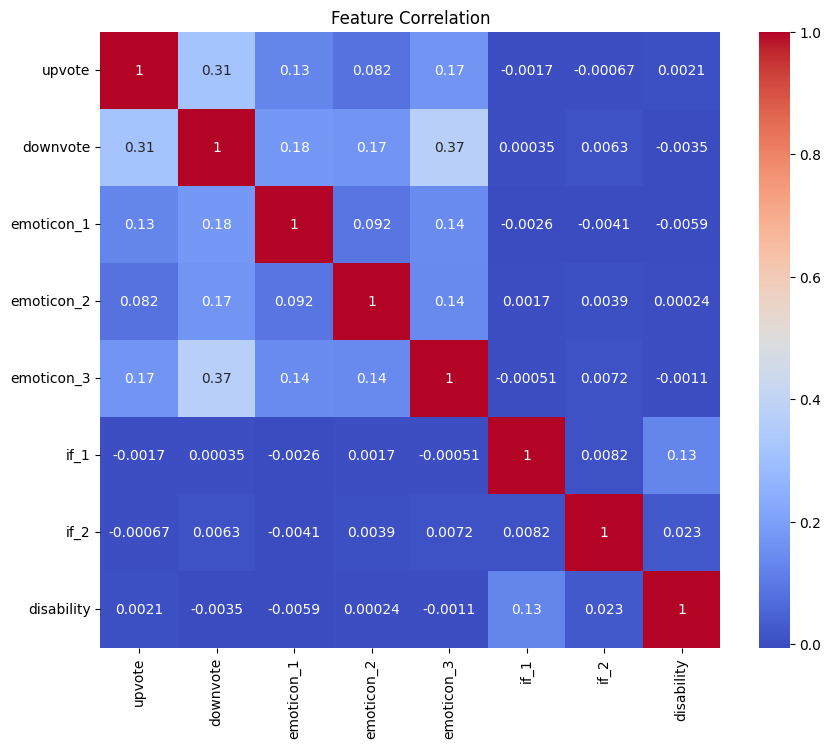

In [21]:
# Correlation heatmap (Numeric features)

num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3',
            'if_1', 'if_2', 'disability'] # Removed 'race', 'religion', 'gender'

plt.figure(figsize=(10,8))
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

* The correlation heatmap shows that most features have low correlation with each other, indicating minimal multicollinearity.
* A few features may have moderate relationships, suggesting some shared patterns but generally independent contributions to the model.

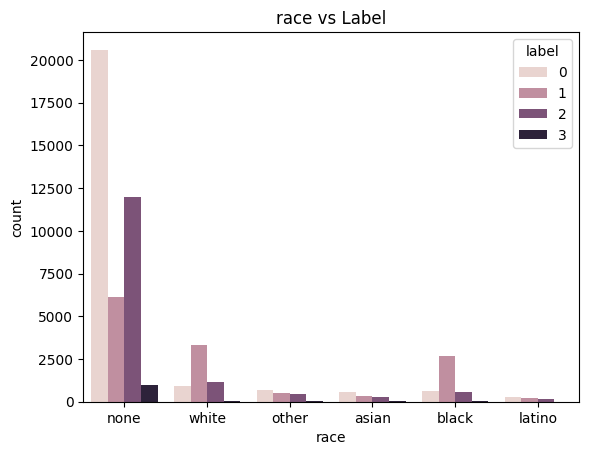

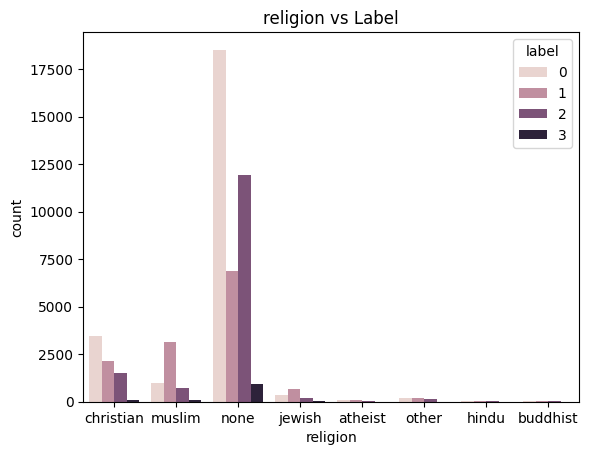

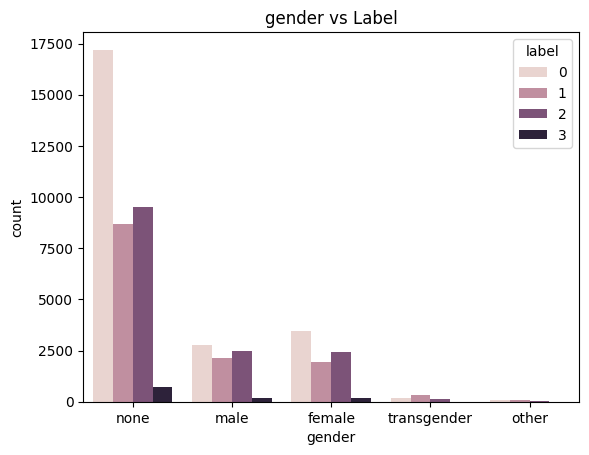

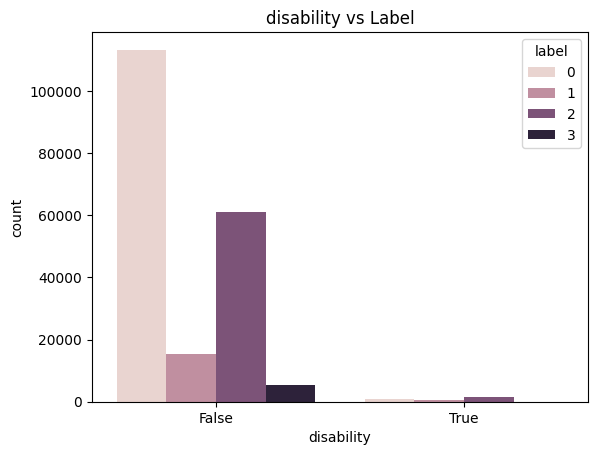

In [22]:
# Category flags vs target 

cat_cols = ['race', 'religion', 'gender', 'disability']

for col in cat_cols:
    sns.countplot(x=col, hue='label', data=train_df)
    plt.title(f"{col} vs Label")
    plt.show()

* The plots show how different categories (race, religion, gender, disability) are distributed across labels, revealing class-wise patterns.
* Some categories may be more associated with specific labels, indicating these features could be useful for prediction.

In [23]:
# Unique values check 

for col in train_df.columns:
    print(f"{col}: {train_df[col].nunique()}")

created_date: 197996
post_id: 52
emoticon_1: 36
emoticon_2: 10
emoticon_3: 16
upvote: 122
downvote: 62
if_1: 57
if_2: 81
race: 6
religion: 8
gender: 5
disability: 2
comment: 197842
label: 4
comment_length: 1007


* The output shows the number of unique values in each column, helping identify categorical vs numerical features.
* Features with very high uniqueness may be less useful or require special handling, while low-cardinality features are easier to encode.

In [24]:
# Duplicate check 

print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0


* The output shows the **number of duplicate rows present** in the dataset.
* If duplicates exist, they should be **removed to prevent bias and improve data quality**.

In [25]:
# Is the dataset imbalanced?

train_df['label'].value_counts(normalize=True)

# Yes, moderately imbalanced

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

* The output shows the **proportion of each class in the dataset**, giving a clear view of class balance.
* It helps confirm whether the dataset is **imbalanced and requires handling techniques**.

In [26]:
# Do emoticons correlate with labels?

pd.crosstab(train_df['emoticon_1'], train_df['label'], normalize='index')

# Yes, Keep all emoticon features , do not drop them

label,0,1,2,3
emoticon_1,,,,
0,0.578674,0.080738,0.312891,0.027697
1,0.556127,0.080360,0.336199,0.027314
2,0.563201,0.076392,0.336092,0.024315
3,0.569433,0.071550,0.325148,0.033870
4,0.593725,0.078037,0.304103,0.024135
5,0.594044,0.078370,0.300940,0.026646
6,0.596257,0.080214,0.288770,0.034759
7,0.640000,0.075556,0.266667,0.017778
8,0.635802,0.061728,0.259259,0.043210


* The crosstab shows how **each emoticon_1 category is distributed across different labels**, highlighting class-wise patterns.
* It indicates that **certain emoticons are more associated with specific labels**, making them useful predictive features.

In [27]:
# Class-wise text patterns

train_df.groupby('label')['comment_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,114173.0,295.897279,269.586161,1.0,93.0,199.0,411.0,1892.0
1,15918.0,335.709700,267.543579,6.0,129.0,246.0,465.0,1006.0
2,62440.0,316.893418,262.830082,3.0,117.0,232.0,437.0,1006.0
3,5469.0,194.171695,194.253112,7.0,68.0,128.0,245.0,1005.0


* The summary shows how **comment length varies across different labels**, including mean, median, and spread.
* It suggests that **some classes tend to have longer or shorter comments**, making length a useful distinguishing feature.

In [28]:
# Top words per class 

from collections import Counter

def get_top_words(texts, n=20):
    # Ensure all items in texts are strings before joining
    words = ' '.join(texts.astype(str)).split()
    return Counter(words).most_common(n)

for label in train_df['label'].unique():
    print(f"\nTop words for class {label}:")
    print(get_top_words(train_df[train_df['label']==label]['comment']))


Top words for class 2:
[('the', 148132), ('to', 92385), ('and', 82279), ('of', 73585), ('a', 71681), ('is', 58640), ('in', 41968), ('that', 40671), ('for', 31534), ('you', 31489), ('are', 29019), ('I', 27426), ('be', 20858), ('with', 20855), ('have', 20489), ('not', 20395), ('on', 20099), ('it', 19543), ('as', 17954), ('they', 17172)]

Top words for class 0:
[('the', 270093), ('to', 163997), ('and', 129545), ('of', 126882), ('a', 116104), ('is', 90067), ('in', 81907), ('that', 73493), ('for', 57536), ('I', 54740), ('you', 44674), ('are', 43668), ('not', 39100), ('be', 38698), ('it', 38113), ('have', 37661), ('on', 36256), ('with', 34617), ('as', 29326), ('they', 28555)]

Top words for class 1:
[('the', 39315), ('to', 23748), ('of', 21267), ('and', 21258), ('a', 17650), ('is', 14740), ('in', 13091), ('that', 11562), ('are', 9414), ('for', 7657), ('you', 7142), ('I', 7027), ('not', 6397), ('be', 5667), ('have', 5531), ('they', 5281), ('as', 5244), ('with', 5114), ('it', 5088), ('on', 48

* The output shows the **most frequent words used in comments for each label**, revealing class-specific vocabulary patterns.
* It indicates that **certain words are strongly associated with particular labels**, which can help improve text-based classification.

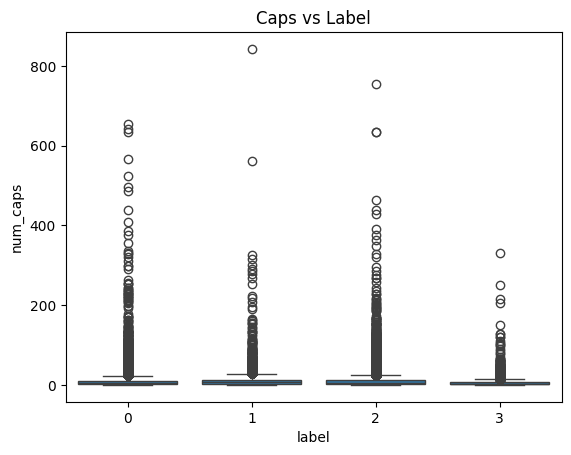

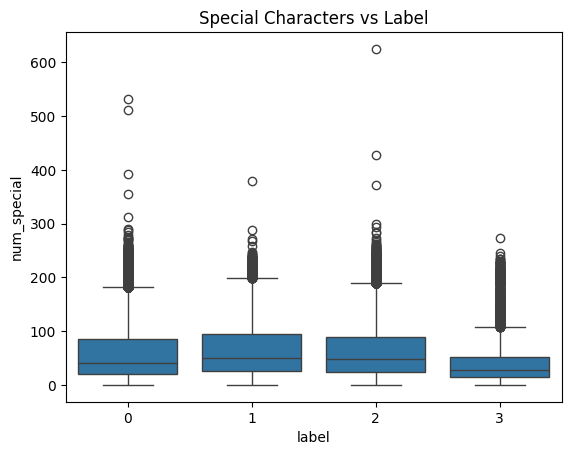

In [29]:
# Special characters & caps analysis

train_df['num_caps'] = train_df['comment'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
train_df['num_special'] = train_df['comment'].apply(lambda x: sum(1 for c in str(x) if not c.isalnum()))

sns.boxplot(x='label', y='num_caps', data=train_df)
plt.title("Caps vs Label")
plt.show()

sns.boxplot(x='label', y='num_special', data=train_df)
plt.title("Special Characters vs Label")
plt.show()

* The plots show that **use of capital letters and special characters varies across labels**, indicating different writing styles.
* These patterns suggest that **text intensity (caps/symbols) can be useful features** for distinguishing between classes.

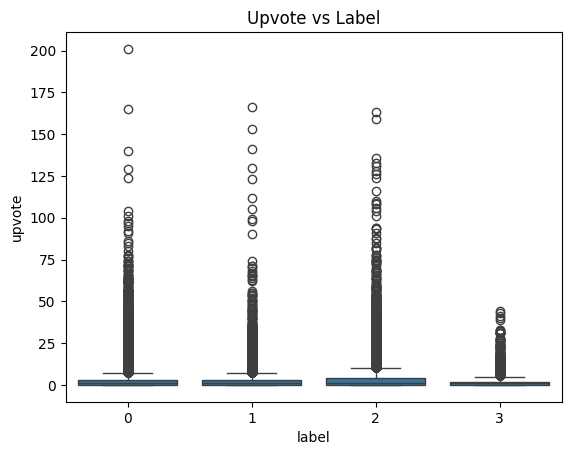

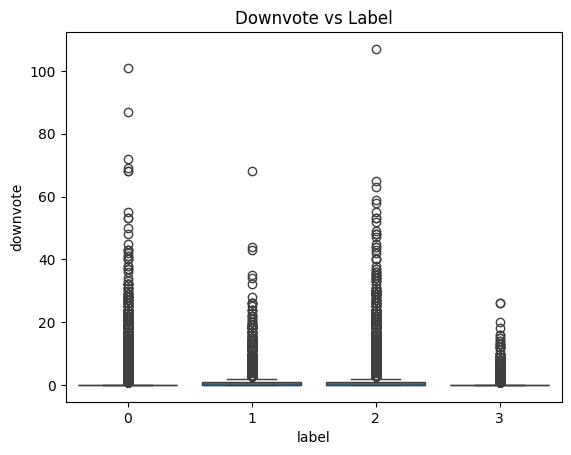

In [30]:
# Upvote/downvote vs label

sns.boxplot(x='label', y='upvote', data=train_df)
plt.title("Upvote vs Label")
plt.show()

sns.boxplot(x='label', y='downvote', data=train_df)
plt.title("Downvote vs Label")
plt.show()

* The plots show that **engagement levels (upvotes and downvotes) differ across labels**, indicating variation in user reactions.
* This suggests that **interaction features can provide useful signals** for predicting the target class.

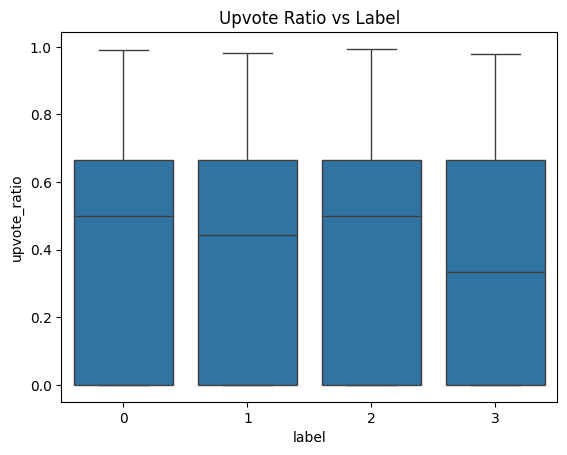

In [31]:
# Upvote ratio feature

train_df['upvote_ratio'] = train_df['upvote'] / (train_df['upvote'] + train_df['downvote'] + 1)

sns.boxplot(x='label', y='upvote_ratio', data=train_df)
plt.title("Upvote Ratio vs Label")
plt.show()

* The upvote ratio shows how **positive engagement varies across different labels**, capturing sentiment more effectively than raw counts.
* This suggests that **relative interaction (ratio) is a strong feature** for distinguishing between classes.

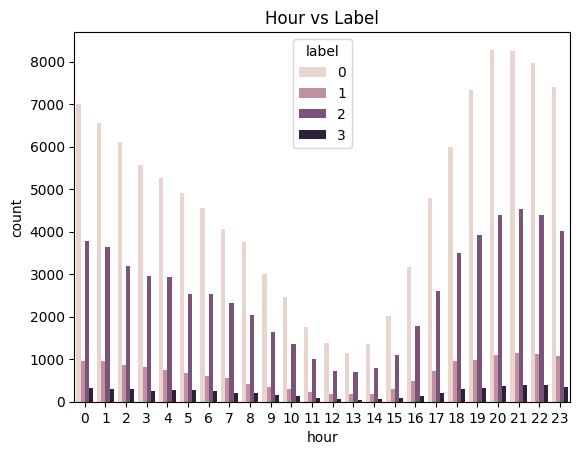

In [32]:
# Time-based features

train_df['created_date'] = pd.to_datetime(train_df['created_date'])

train_df['hour'] = train_df['created_date'].dt.hour
train_df['day'] = train_df['created_date'].dt.dayofweek

sns.countplot(x='hour', hue='label', data=train_df)
plt.title("Hour vs Label")
plt.show()

* The distribution shows how **comments across labels vary by hour of the day**, indicating time-based activity patterns.
* This suggests that **temporal features (like hour) may influence label prediction** and can improve model performance.

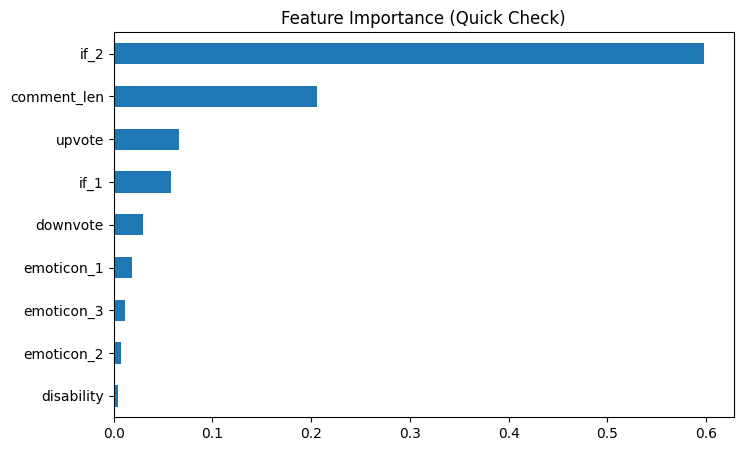

In [33]:
# Feature importance preview

from sklearn.ensemble import RandomForestClassifier

# Ensure 'comment_len' is created before sampling
train_df['comment_len'] = train_df['comment'].astype(str).apply(lambda x: len(x.split()))

sample = train_df.sample(5000)

features = num_cols + ['comment_len'] # Corrected 'num_features' to 'num_cols' and 'word_count' to 'comment_len'
X_temp = sample[features]
y_temp = sample['label']

rf = RandomForestClassifier()
rf.fit(X_temp, y_temp)

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance (Quick Check)")
plt.show()

* The feature importance plot shows which features have the **highest impact on predicting the target label**.
* It indicates that **certain features (like engagement or text length) are more influential**, helping in feature selection and model improvement.

In [34]:
# Label vs emoticon patterns

for col in ['emoticon_1', 'emoticon_2', 'emoticon_3']:
    print(pd.crosstab(train_df[col], train_df['label'], normalize='index'))

label              0         1         2         3
emoticon_1                                        
0           0.578674  0.080738  0.312891  0.027697
1           0.556127  0.080360  0.336199  0.027314
2           0.563201  0.076392  0.336092  0.024315
3           0.569433  0.071550  0.325148  0.033870
4           0.593725  0.078037  0.304103  0.024135
5           0.594044  0.078370  0.300940  0.026646
6           0.596257  0.080214  0.288770  0.034759
7           0.640000  0.075556  0.266667  0.017778
8           0.635802  0.061728  0.259259  0.043210
9           0.705882  0.088235  0.186275  0.019608
10          0.695652  0.057971  0.217391  0.028986
11          0.676471  0.073529  0.220588  0.029412
12          0.675000  0.100000  0.225000  0.000000
13          0.740741  0.074074  0.185185  0.000000
14          0.631579  0.000000  0.263158  0.105263
15          0.700000  0.050000  0.200000  0.050000
16          0.600000  0.000000  0.400000  0.000000
17          0.777778  0.000000 

* The crosstabs show how **each emoticon category is proportionally distributed across labels**, highlighting class-wise associations.
* It confirms that **certain emoticons are more likely linked to specific labels**, making them useful predictive features.

# EDA Insights Summary 

* The dataset shows class imbalance, which can bias the model → requires proper evaluation metrics or resampling.
  
* Text features (words, length, caps, special characters) vary across labels → strong indicators for classification.

  
* Emoticons and categorical features show clear associations with certain labels → useful predictive signals.

  
* Engagement features (upvotes, downvotes, ratio) differ by class → reflect user sentiment and importance.

  
* Most numerical features are skewed with outliers → scaling or transformation is needed.

  
* Low correlation between features indicates minimal redundancy and good feature diversity.

  
* Temporal patterns (hour/day) suggest user behavior varies with time → useful additional feature.

  
* Feature importance confirms that text length and interaction features are among the most influential.

# Data Cleaning and Preprocessing

In [35]:
train_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
197995    False
197996    False
197997    False
197998    False
197999    False
Length: 198000, dtype: bool

In [36]:
# total number of duplicate rows present

print(train_df.duplicated().sum())

0


In [37]:
# null values

train_df.isnull()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,disability,comment,label,comment_length,num_caps,num_special,upvote_ratio,hour,day,comment_len
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
197996,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
197997,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
197998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [38]:
# column wise number of null values

train_df.isnull().sum()

created_date           0
post_id                0
emoticon_1             0
emoticon_2             0
emoticon_3             0
upvote                 0
downvote               0
if_1                   0
if_2                   0
race              145423
religion          145423
gender            145423
disability             0
comment                1
label                  0
comment_length         0
num_caps               0
num_special            0
upvote_ratio           0
hour                   0
day                    0
comment_len            0
dtype: int64

In [39]:
# Handling missing values

text_columns = ['comment']
cat_columns = ['race','religion','gender']

for col in text_columns + cat_columns:
    train_df[col] = train_df[col].fillna("missing")
    test_df[col] = test_df[col].fillna("missing")

* Missing values in text and categorical columns are **replaced with a placeholder ("missing")**, ensuring no null values remain.
* This prevents errors during modeling and allows **models to treat missing data as a separate category**.

In [40]:
# lets see the column

train_df[col]

0         missing
1         missing
2         missing
3         missing
4         missing
           ...   
197995    missing
197996    missing
197997    missing
197998       none
197999       none
Name: gender, Length: 198000, dtype: object

In [41]:
# lets see the column

test_df[col]

0         missing
1         missing
2         missing
3         missing
4         missing
           ...   
101995    missing
101996     female
101997       none
101998    missing
101999    missing
Name: gender, Length: 102000, dtype: object

In [42]:
# Comment length

train_df["comment_len"] = train_df["comment"].str.split().str.len()

test_df["comment_len"] = test_df["comment"].str.split().str.len()

* A new feature **comment_len** is created to capture the **number of words in each comment**.
* This helps the model use **text length as a meaningful signal**, which may vary across different labels.

In [43]:
# lets see the column

train_df["comment_len"]

0          20
1         110
2         133
3          15
4          40
         ... 
197995     21
197996     18
197997     23
197998     22
197999     35
Name: comment_len, Length: 198000, dtype: int64

In [44]:
# lets see the column

test_df["comment_len"]

0         12
1          6
2          1
3         23
4         17
          ..
101995    54
101996    45
101997     6
101998    13
101999    86
Name: comment_len, Length: 102000, dtype: int64

In [45]:
# disability type before

train_df["disability"]

0         False
1         False
2         False
3         False
4         False
          ...  
197995    False
197996    False
197997    False
197998    False
197999    False
Name: disability, Length: 198000, dtype: bool

In [46]:
# data type conversion

train_df["disability"] = train_df["disability"].astype(int)

test_df["disability"] = test_df["disability"].astype(int)

* The **disability feature is converted to integer type**, ensuring it is in a numeric format suitable for modeling.
* This allows the model to **properly interpret and use this feature as a numerical input**.

In [47]:
# disability type after

train_df["disability"]

0         0
1         0
2         0
3         0
4         0
         ..
197995    0
197996    0
197997    0
197998    0
197999    0
Name: disability, Length: 198000, dtype: int64

In [48]:
# Separating features and target variable

X = train_df.drop(columns=['created_date','label']) # droping 2 columns it should not be included in inputs
y = train_df['label'] # your model will try to predict

* The dataset is split into **input features (X)** by removing non-relevant columns and the target.
* The **target variable (y)** is separated, which the model will learn to predict.

In [49]:
X     # all useful independent variables (features)

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,comment_length,num_caps,num_special,upvote_ratio,hour,day,comment_len
0,73,0,0,0,0,1,0,10,missing,missing,missing,0,She might be a bright spot for a party keou on...,118,2,20,0.000000,8,3,20
1,39,0,0,0,6,0,0,4,missing,missing,missing,0,"Under Alaska law, a non-tribal member is not b...",644,9,124,0.857143,21,6,110
2,31,0,1,1,0,0,0,10,missing,missing,missing,0,in the future please spare me your strawman dr...,751,13,150,0.000000,20,2,133
3,39,0,0,0,5,0,0,10,missing,missing,missing,0,"PS: That should have been ""rot"" instead of ""co...",91,4,22,0.833333,22,6,15
4,39,0,0,0,0,0,0,10,missing,missing,missing,0,"Today, the confederate flag...tomorrow, the na...",254,3,59,0.000000,23,5,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,39,0,0,0,2,0,0,4,missing,missing,missing,0,Why save people who are bent on self-destructi...,120,2,23,0.666667,10,5,21
197996,72,0,0,0,1,0,0,10,missing,missing,missing,0,Trudeau is not only undemocratic but also innu...,122,1,20,0.500000,17,2,18
197997,72,0,0,0,0,0,0,10,missing,missing,missing,0,block all exports no humanitarian relief and a...,122,2,23,0.000000,15,5,23
197998,72,0,1,1,5,7,4,10,black,none,none,0,really black kids seeing that is better than g...,141,0,22,0.384615,17,0,22


In [50]:
y   # dependent variable (output)

0         2
1         0
2         2
3         2
4         2
         ..
197995    0
197996    2
197997    3
197998    1
197999    0
Name: label, Length: 198000, dtype: int64

In [51]:
# Train–validation split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

* The data is split into **training and validation sets (80–20 split)** to evaluate model performance on unseen data.
* Stratification ensures the **class distribution remains consistent**, preventing bias during training and evaluation.

# Feature Engineering

In [52]:
# Defining feature groups

text_features = 'comment'
categorical_features = ['race','religion','gender']
numeric_features = [
    "emoticon_1","emoticon_2","emoticon_3",
    "upvote","downvote","if_1","if_2",
    "comment_len","disability","post_id"
]

In [53]:
# Preprocessing using Column Transformer

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer( stop_words="english",
    max_df=0.9,
    min_df=10,
    ngram_range=(1,1),
    sublinear_tf=True), text_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

* Different preprocessing techniques are applied to each feature type: **TF-IDF for text, One-Hot Encoding for categorical, and scaling for numerical features**.
* This ensures all features are **properly transformed into a machine-readable format**, improving model performance and consistency.

In [54]:
class_weight = {0:1,1:2,2:1,3:3}

* Class weights are assigned to **handle class imbalance**, giving more importance to underrepresented classes.
* This helps the model **learn minority classes better and reduces bias toward majority classes**.

# Model Training

In [55]:
# Logistic Regression Pipeline

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        solver='lbfgs',    # efficient for multi-class problems
        penalty="l2",      # prevents overfitting
        C=0.6,             # controls regularization strength
        max_iter=5000,     # ensures convergence
        class_weight= {0:1,1:2,2:1,3:3} # handles class imbalance
    ))
])


# Training Logistic Regression Model

logistic_pipeline.fit(X_train, y_train)

preds = logistic_pipeline.predict(X_val)

f1 = f1_score(y_val, preds, average='macro')
print("Logistic Regression F1:", f1)

Logistic Regression F1: 0.8121208350118315


In [56]:
# Random Forest Pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,    # uses more trees for better performance
        max_depth=20,        # controls overfitting
        random_state=42      # ensures reproducibility
    ))
])

# Training Random Forest Model

rf_pipeline.fit(X_train, y_train)

preds = rf_pipeline.predict(X_val)

f1 = f1_score(y_val, preds, average='macro')
print("Random Forest F1:", f1)

Random Forest F1: 0.2986745807516281


In [57]:
import lightgbm as lgb

# LightGBM Pipeline

lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(random_state=42)) # ensures reproducible results by fixing randomness in the model
])

# Training LightGBM Model

lgbm_pipeline.fit(X_train, y_train)

preds = lgbm_pipeline.predict(X_val)

f1 = f1_score(y_val, preds, average='macro')
print("LightGBM F1:", f1)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 16.767733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 774770
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 15475
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM F1: 0.797908597001983


In [58]:
import xgboost as xgb

# XGBoost Pipeline

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(random_state=42, # ensures reproducibility
              eval_metric='mlogloss')) # suitable loss function for multi-class classification
])

# Training XGBoost Model

xgb_pipeline.fit(X_train, y_train)

preds = xgb_pipeline.predict(X_val)

f1 = f1_score(y_val, preds, average='macro')
print("XGBoost F1:", f1)

XGBoost F1: 0.780954574430065


In [59]:
# Support Vector Machine Pipeline

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearSVC())
])

# Training SVM Model

svm_pipeline.fit(X_train, y_train)

preds = svm_pipeline.predict(X_val)

f1 = f1_score(y_val, preds, average='macro')
print("SVM F1:", f1)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM F1: 0.6759188861455075


In [60]:
# Comparing Different Models for Best Results

results = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "LightGBM": lgbm_pipeline,
    "XGBoost": xgb_pipeline,
    "Linear SVM": svm_pipeline
}

for name, model in results.items():
    preds = model.predict(X_val)
    f1 = f1_score(y_val, preds, average='macro')
    print(name, "F1:", f1)

Logistic Regression F1: 0.8121208350118315
Random Forest F1: 0.2986745807516281


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM F1: 0.797908597001983
XGBoost F1: 0.780954574430065
Linear SVM F1: 0.6759188861455075


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_55/3234447488.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1 Score (Macro)', y='Model', data=comparison_df, palette='viridis')


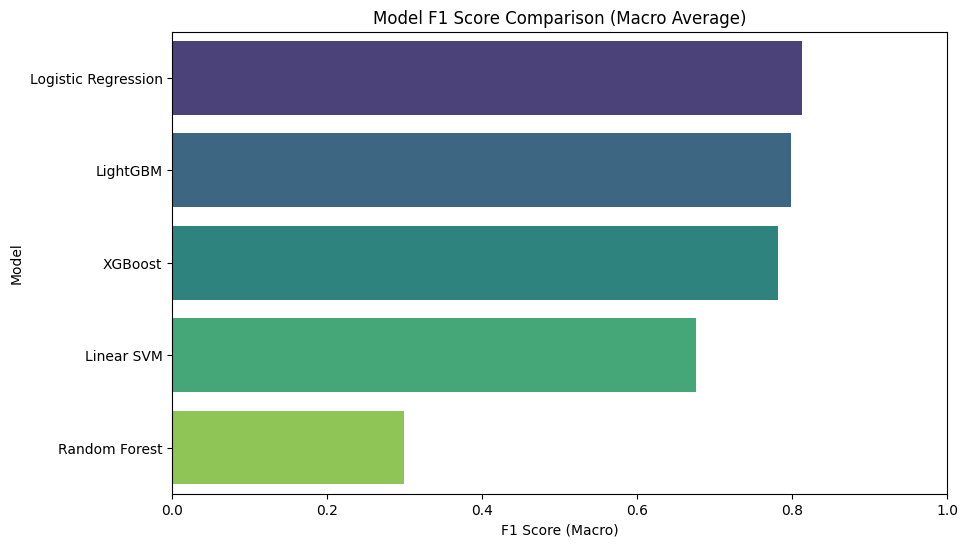

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = []
f1_scores = []

for name, model in results.items():
    preds = model.predict(X_val)
    f1 = f1_score(y_val, preds, average='macro')
    model_names.append(name)
    f1_scores.append(f1)

# Create a DataFrame for easy plotting
comparison_df = pd.DataFrame({
    'Model': model_names,
    'F1 Score (Macro)': f1_scores
}).sort_values(by='F1 Score (Macro)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='F1 Score (Macro)', y='Model', data=comparison_df, palette='viridis')
plt.title('Model F1 Score Comparison (Macro Average)')
plt.xlabel('F1 Score (Macro)')
plt.ylabel('Model')
plt.xlim(0, 1) # F1 score is between 0 and 1
plt.show()

## Insights from Model Comparison :-

1. Logistic Regression has the highest F1 score.
2. Tree based models such as Random Forest and XGBoost performs slightly well.
3. SVM has a modrate performance due to high dimentional sparse data.
4. TF-IDF feature works well with the linear i.e. Logistic Regression.

In [62]:
# Selecting and Training the Final Model 

best_model = logistic_pipeline
best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.9,
                                                                  min_df=10,
                                                                  stop_words='english',
                                                                  sublinear_tf=True),
                                                  'comment'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'religion',
                                                   'gender']),
                                                 ('num', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'upvote',
                                                   'downvote', 'if_1', 'if_2',
                                                   'comment_len', 'disability',
                                                   'post_id'])])),
                ('model',
                 LogisticRegression(C=0.6,
                                    class_weight={0: 1, 1: 2, 2: 1, 3: 3},
                                    max_iter=5000))])

In [63]:
# Preprocessing the test dataset

for col in text_columns + cat_columns:
    test_df[col] = test_df[col].fillna("missing")

test_df['created_date'] = pd.to_datetime(test_df['created_date'])
test_df['year'] = test_df['created_date'].dt.year
test_df['month'] = test_df['created_date'].dt.month
test_df['day'] = test_df['created_date'].dt.day

print("Preprocessing of test_df complete.")

Preprocessing of test_df complete.


* Missing values in test data are handled and **date features are extracted (year, month, day)** to match training preprocessing.
* This ensures the test data is **clean, consistent, and ready for model prediction**.

In [64]:
# Hyperparameter Tuning the best model which is Logistic Regression Model

from sklearn.model_selection import GridSearchCV

# Define the class_weight dictionary
class_weight_dict = {0:1,1:2,2:1,3:3}

param_grid = {
    'model__C': [0.1, 0.5, 1, 2],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__class_weight': ["balanced", class_weight_dict]
}

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid,  # # tests different values of C, solver, and class_weight
    cv=3,   # ensures reliable evaluation
    scoring='f1_macro',   # handles class imbalance
    verbose=2,
    n_jobs=-1   # uses all CPU cores for faster computation
)

print("Starting GridSearchCV for Logistic Regression...")
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation F1-macro score:", grid_search.best_score_)

Starting GridSearchCV for Logistic Regression...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters found: {'model__C': 1, 'model__class_weight': {0: 1, 1: 2, 2: 1, 3: 3}, 'model__solver': 'lbfgs'}
Best cross-validation F1-macro score: 0.8082548168303934


In [65]:
# Traing Best Model which is Logistic Regression

best_lr_model = grid_search.best_estimator_
best_lr_model.fit(X, y)

print("Best Logistic Regression model trained on the full dataset.")

Best Logistic Regression model trained on the full dataset.


In [66]:
# Predictions on test data

test_predictions = best_lr_model.predict(test_df)
print("Predictions on test_df complete.")

Predictions on test_df complete.


* The trained model is used to **generate predictions on the unseen test dataset**.
* This step produces the **final outputs for evaluation or competition submission**.

In [67]:
# Creating final submission file

submission_df = pd.DataFrame({
    'ID': sample_submission.ID,
    'label': test_predictions
})

submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")

Submission file 'submission.csv' created successfully.
[CV] END model__C=0.1, model__class_weight=balanced, model__solver=liblinear; total time=  52.3s
[CV] END model__C=0.1, model__class_weight={0: 1, 1: 2, 2: 1, 3: 3}, model__solver=liblinear; total time=  38.9s
[CV] END model__C=0.1, model__class_weight={0: 1, 1: 2, 2: 1, 3: 3}, model__solver=lbfgs; total time=  30.3s
[CV] END model__C=0.5, model__class_weight=balanced, model__solver=liblinear; total time= 1.4min
[CV] END model__C=0.5, model__class_weight={0: 1, 1: 2, 2: 1, 3: 3}, model__solver=liblinear; total time= 1.0min
[CV] END model__C=0.5, model__class_weight={0: 1, 1: 2, 2: 1, 3: 3}, model__solver=lbfgs; total time=  43.9s
[CV] END model__C=1, model__class_weight=balanced, model__solver=liblinear; total time= 1.6min
[CV] END model__C=1, model__class_weight={0: 1, 1: 2, 2: 1, 3: 3}, model__solver=liblinear; total time= 1.1min
[CV] END model__C=1, model__class_weight={0: 1, 1: 2, 2: 1, 3: 3}, model__solver=lbfgs; total time=  

This project demonstrates how combining NLP with structured data and proper feature engineering can significantly improve classification performance in real-world noisy datasets.